In [1]:
!pip install scipy

# Problem 2: Demographic Epicycle

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
metadata = pd.read_csv('IMDb movies.csv')
ratings = pd.read_csv('IMDb ratings.csv')
df = pd.concat([metadata, ratings], axis=1)

mask = df.columns.duplicated()
df = df.loc[:, ~mask]

/var/folders/2b/gxmh627x4vvgpqmv_3dzvbq80000gn/T/ipykernel_77255/73648191.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv('IMDb movies.csv')


In [4]:
genre = df['genre'].str.split(',').explode().str.strip().unique()
print(genre)
actionStrings = ['Adventure', 'Thriller', 'Action', 'War']

actionPattern = '|'.join(actionStrings)
df['isAction'] = df['genre'].str.contains(actionPattern, regex=True)

['Romance' 'Biography' 'Crime' 'Drama' 'History' 'Adventure' 'Fantasy'
 'War' 'Mystery' 'Horror' 'Western' 'Comedy' 'Family' 'Action' 'Sci-Fi'
 'Thriller' 'Sport' 'Animation' 'Musical' 'Music' 'Film-Noir' 'Adult'
 'Documentary' 'Reality-TV' 'News']


In [5]:
# avg ratings (1-10) per group
votes = ['males_0age_avg_vote', 'males_18age_avg_vote', 
         'males_30age_avg_vote', 'males_45age_avg_vote', 
         'females_0age_avg_vote', 'females_18age_avg_vote',
         'females_30age_avg_vote', 'females_45age_avg_vote',
         'males_allages_avg_vote', 'females_allages_avg_vote',
         'allgenders_0age_avg_vote', 'allgenders_18age_avg_vote',
         'allgenders_30age_avg_vote', 'allgenders_45age_avg_vote']
# num of voters per group
counts = ['males_0age_votes', 'males_18age_votes', 
           'males_30age_votes', 'males_45age_votes',
           'females_0age_votes', 'females_18age_votes',
           'females_30age_votes', 'females_45age_votes',
           'males_allages_votes', 'females_allages_votes',
           'allgenders_0age_votes', 'allgenders_18age_votes',
           'allgenders_30age_votes', 'allgenders_45age_votes']

filtered = df[(df[counts] >= 20).all(axis=1) & df[counts].notna().all(axis=1) & df[votes].notna().all(axis=1)].copy()
df_action = filtered[filtered['isAction']].copy()

def weightedAvg(dataframe, votes, counts):
    return np.average(dataframe[votes], weights=dataframe[counts], axis=1)

df_action['ym_rating'] = weightedAvg(df_action, votes[0:2], counts[0:2])
df_action['om_rating'] = weightedAvg(df_action, votes[2:4], counts[2:4])
df_action['yf_rating'] = weightedAvg(df_action, votes[4:6], counts[4:6])
df_action['of_rating'] = weightedAvg(df_action, votes[6:8], counts[6:8])
df_action['m_rating'] = weightedAvg(df_action, votes[8:9], counts[8:9])
df_action['f_rating'] = weightedAvg(df_action, votes[9:10], counts[9:10])
df_action['y_rating'] = weightedAvg(df_action, votes[10:12], counts[10:12])
df_action['o_rating'] = weightedAvg(df_action, votes[12:14], counts[12:14])

print('Avg ratings')
print(f"Young males: {df_action['ym_rating'].mean()}")
print(f"Old males: {df_action['om_rating'].mean()}")
print(f"Young females: {df_action['yf_rating'].mean()}")
print(f"Old females: {df_action['of_rating'].mean()}'")

diff1 = df_action['yf_rating'].mean() - df_action['ym_rating'].mean()
diff2 = df_action['of_rating'].mean() - df_action['om_rating'].mean()
print(f"Females rate action movies {diff1}, {diff2} higher than males")
diff3 = df_action['yf_rating'].mean() - df_action['of_rating'].mean()
diff4 = df_action['ym_rating'].mean() - df_action['om_rating'].mean()
print(f"Young gen rate action movies {diff3}, {diff4} higher than old")
# females rate action movies higher than males
# young gen rate action movies higher than old

df_action['mAge_diff'] = np.subtract(df_action['ym_rating'], df_action['om_rating'])
df_action['fAge_diff'] = np.subtract(df_action['yf_rating'], df_action['of_rating'])

Avg ratings
Young males: 7.153530986307276
Old males: 7.010352624145885
Young females: 7.329499476631168
Old females: 7.199835753971791'
Females rate action movies 0.17596849032389184, 0.18948312982590565 higher than males
Young gen rate action movies 0.12966372265937665, 0.14317836216139046 higher than old


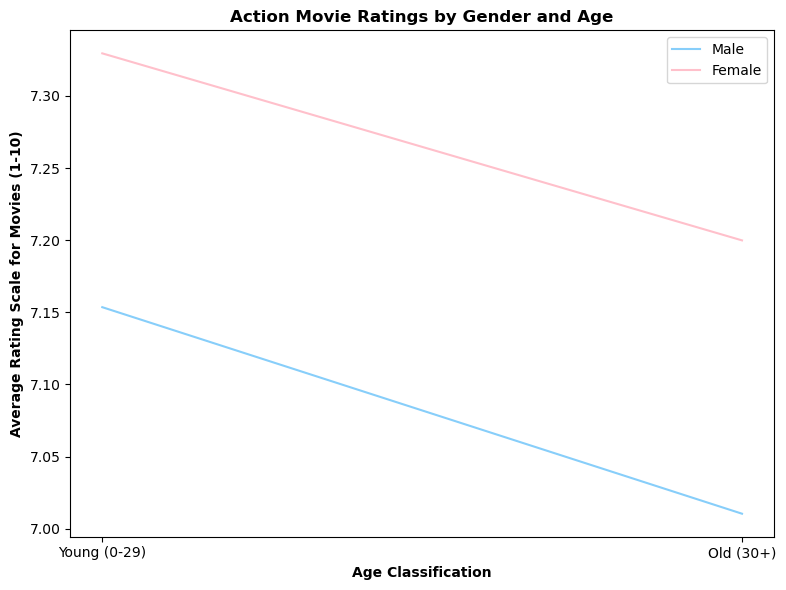

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

a = {'ym_avg': df_action['ym_rating'].mean(),
     'om_avg': df_action['om_rating'].mean(),
     'yf_avg': df_action['yf_rating'].mean(),
     'of_avg': df_action['of_rating'].mean()}

ax.plot(['Young (0-29)', 'Old (30+)'], [a['ym_avg'], a['om_avg']], color='lightskyblue', label='Male')
ax.plot(['Young (0-29)', 'Old (30+)'], [a['yf_avg'], a['of_avg']], color='pink', label='Female')
ax.set_xlabel('Age Classification', fontweight='bold')
ax.set_ylabel('Average Rating Scale for Movies (1-10)', fontweight='bold')
ax.set_title('Action Movie Ratings by Gender and Age', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

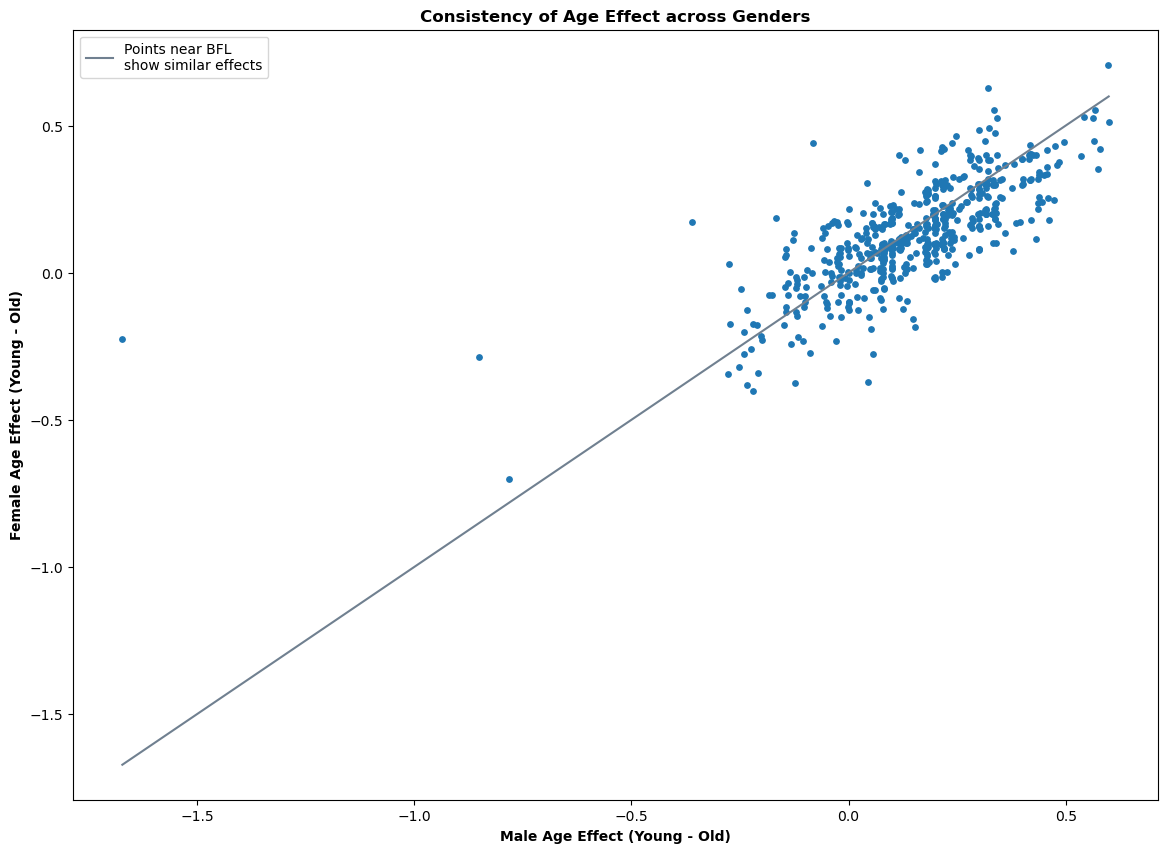

In [7]:
fig, ax = plt.subplots(figsize=(14, 10))

ax.scatter(df_action['mAge_diff'], df_action['fAge_diff'], s=15)
ax.plot([df_action['mAge_diff'].min(), df_action['mAge_diff'].max()],
         [df_action['mAge_diff'].min(), df_action['mAge_diff'].max()],
         color='slategrey',
         label='Points near BFL\nshow similar effects')
ax.set_xlabel('Male Age Effect (Young - Old)', fontweight='bold')
ax.set_ylabel('Female Age Effect (Young - Old)', fontweight='bold')
ax.set_title('Consistency of Age Effect across Genders',fontweight='bold')
ax.legend()
plt.show()

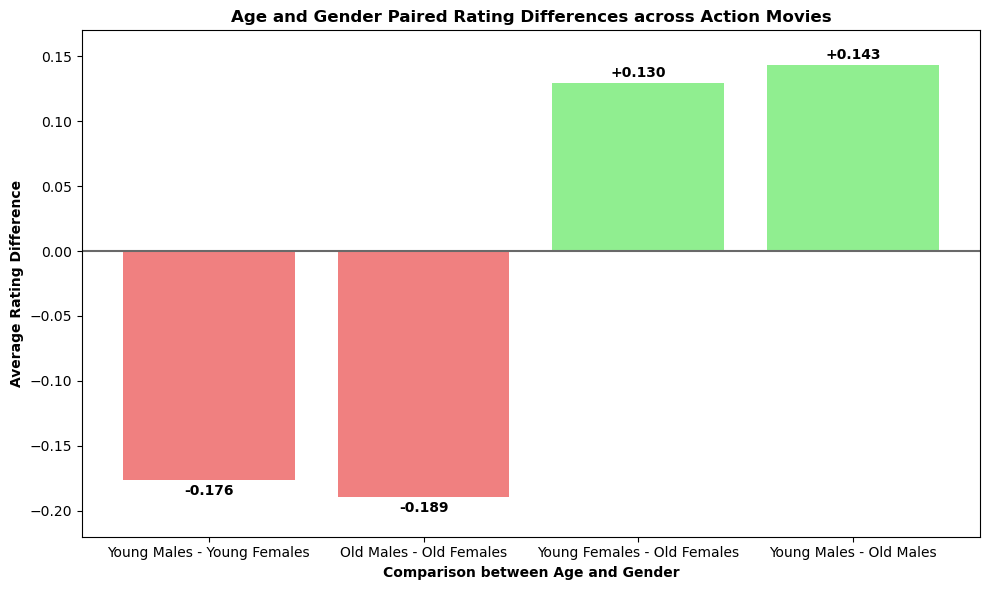

{'Young Males - Young Females': np.float64(-0.17596849032389184), 'Old Males - Old Females': np.float64(-0.18948312982590565), 'Young Females - Old Females': np.float64(0.12966372265937665), 'Young Males - Old Males': np.float64(0.14317836216139046)}


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

d = {'Young Males - Young Females': -diff1,
     'Old Males - Old Females': -diff2,
     'Young Females - Old Females': diff3,
     'Young Males - Old Males': diff4}

colors = ['lightgreen' if val > 0 else 'lightcoral' for val in d.values()]
bars = ax.bar(range(len(d)), list(d.values()), color=colors)
ax.axhline(y=0, color='dimgray')
ax.set_ylabel('Average Rating Difference', fontweight='bold')
ax.set_xlabel('Comparison between Age and Gender', fontweight='bold')
ax.set_title('Age and Gender Paired Rating Differences across Action Movies', fontweight='bold')
ax.set_xticks(range(len(d)))
ax.set_xticklabels(list(d.keys()))
ax.set_ylim(-.22, .17)

ax.text(0, -.188, '-0.176', ha='center', fontweight='bold')
ax.text(1, -.201, '-0.189', ha='center', fontweight='bold')
ax.text(2, .134, '+0.130', ha='center', fontweight='bold')
ax.text(3, .148, '+0.143', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print(d)

In [9]:
# Age has same effect across female and males
t, p = stats.ttest_rel(df_action['mAge_diff'], df_action['fAge_diff'])
print(t, p)
# fail to reject null p=0.21 > 0.05
# df_action.loc[df_action['fAge_diff'].isna(),'fAge_diff']

2.3692130967891347 0.01816539753556942


In [10]:
# Gender has no effect on rating
t, p = stats.ttest_rel(df_action['f_rating'],df_action['m_rating'])
print(t, p)
# reject null p=0.0001 < 0.05
# df_action.loc[df_action['m_rating'].isna(),'m_rating']

13.818291005453997 1.4532715376382099e-37


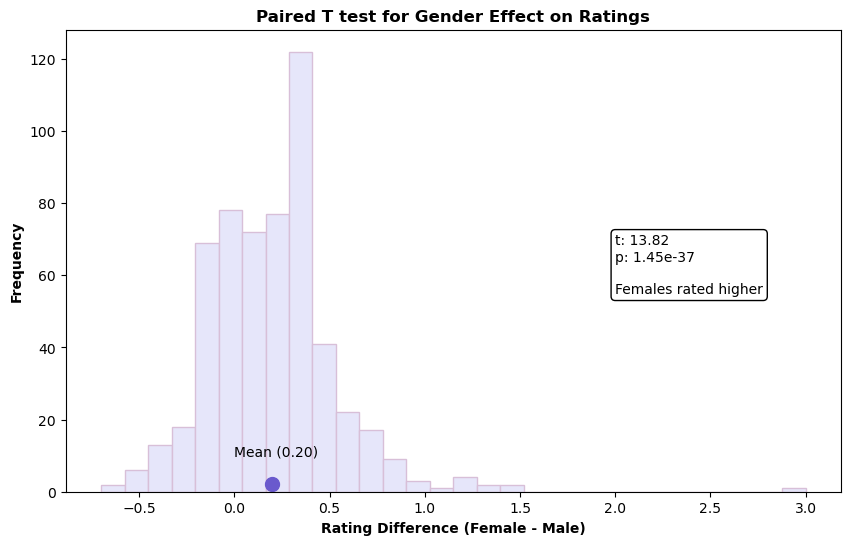

0.19749552772808587


In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
gender_diff = df_action['f_rating'] - df_action['m_rating']
ax.hist(gender_diff, bins=30, color='lavender', edgecolor='thistle')
ax.plot(gender_diff.mean(), 2.2, 'o',color='slateblue', markersize=10)
ax.text(0, 10, 'Mean (0.20)')
ax.set_xlabel('Rating Difference (Female - Male)', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_title('Paired T test for Gender Effect on Ratings', fontweight='bold')
ax.text(2, 55, 't: 13.82\np: 1.45e-37\n\nFemales rated higher', bbox=dict(boxstyle='round', fc='white'))
plt.show()
print(gender_diff.mean())

In [12]:
# Age has no effect on rating
t, p = stats.ttest_rel(df_action['y_rating'],df_action['o_rating'])
print(t, p)
# reject null p=0.003 < 0.05
# df_action.loc[df_action['y_rating'].isna(),'o_rating']

20.67431042890487 6.28792152815943e-71


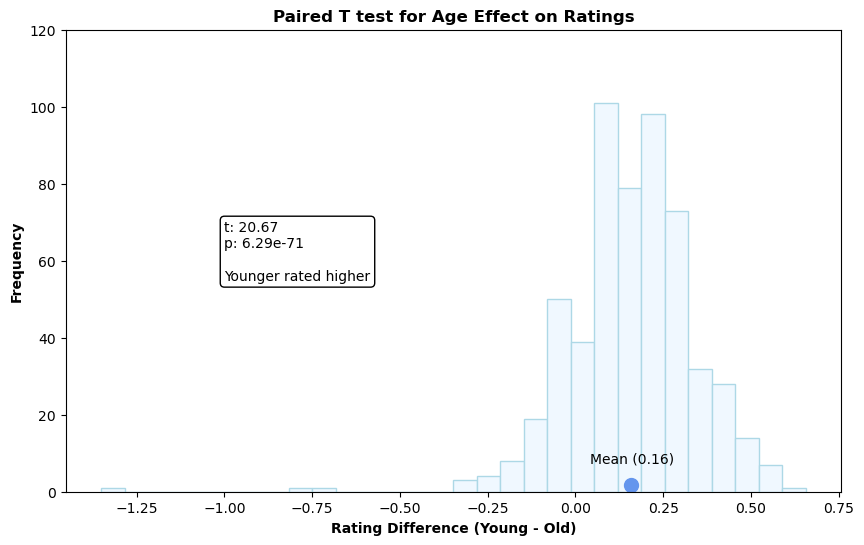

0.15912957676375197


In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
age_diff = df_action['y_rating'] - df_action['o_rating']
ax.hist(age_diff, bins=30, color='aliceblue', edgecolor='lightblue')
ax.plot(age_diff.mean(), 1.8, 'o',color='cornflowerblue', markersize=10)
ax.text(0.04, 7.5, 'Mean (0.16)')
ax.set_xlabel('Rating Difference (Young - Old)', fontweight='bold')
ax.set_ylabel('Frequency', fontweight='bold')
ax.set_ylim(0, 120)
ax.set_title('Paired T test for Age Effect on Ratings', fontweight='bold')
ax.text(-1, 55, 't: 20.67\np: 6.29e-71\n\nYounger rated higher', bbox=dict(boxstyle='round', fc='white'))
plt.show()
print(age_diff.mean())